# Lectura de datos

In [15]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
import locale
import calendar
import math

# Establecer localización en español
locale.setlocale(locale.LC_TIME, 'es_ES.UTF-8')

# Cargar el archivo NetCDF
data_boyaca = xr.open_dataset('../../data/boyaca_region_monthly_sum.nc')

# Convertir a DataFrame y resetear índices para que las coordenadas y tiempo sean columnas
df_boyaca = data_boyaca.to_dataframe().reset_index()

# Verificar columnas
print("Columnas disponibles:", df_boyaca.columns)

# Si existe una columna 'YYYY-MM' la usamos, si no, generamos 'time'
if 'YYYY-MM' in df_boyaca.columns:
    df_boyaca['time'] = pd.to_datetime(df_boyaca['YYYY-MM'])
else:
    df_boyaca['time'] = pd.to_datetime(df_boyaca['time'], errors='coerce')

# Extraer año y mes como números y nombres en español
df_boyaca['year'] = df_boyaca['time'].dt.year
df_boyaca['month'] = df_boyaca['time'].dt.month
df_boyaca['month_name'] = df_boyaca['month'].apply(lambda x: calendar.month_name[x]).str.capitalize()

# Verificación de las columnas de coordenadas
if 'latitude' not in df_boyaca.columns or 'longitude' not in df_boyaca.columns:
    # Si no existen, tratar de usar las versiones 'latitude_val' y 'longitude_val'
    if 'latitude_val' in df_boyaca.columns and 'longitude_val' in df_boyaca.columns:
        df_boyaca['latitude'] = df_boyaca['latitude_val']
        df_boyaca['longitude'] = df_boyaca['longitude_val']
    else:
        raise KeyError("No se encontraron columnas 'latitude'/'longitude' ni 'latitude_val'/'longitude_val'.")

# Eliminar filas con NaN
df_boyaca = df_boyaca.dropna(subset=['latitude', 'longitude', 'total_precipitation'])

# Mantener solo columnas relevantes
data = df_boyaca[['latitude', 'longitude', 'year', 'month', 'month_name', 'total_precipitation']].copy()

# (Opcional) Filtrar si se desea eliminar un mes específico
# data = data[~((data['year'] == 2023) & (data['month'] == 5))]

# Mostrar muestra
print(data.sample(5))


Columnas disponibles: Index(['time', 'latitude', 'longitude', 'total_precipitation',
       'max_daily_precipitation', 'min_daily_precipitation', 'YYYY-MM', 'YYYY',
       'MM'],
      dtype='object')
         latitude  longitude  year  month month_name  total_precipitation
90042    6.524998 -73.475006  1983      4      Abril           314.266541
202313   5.324997 -74.325005  1986      3      Marzo           118.637505
824967   7.274998 -73.125008  2002      2    Febrero            70.094231
1029824  4.674999 -73.075005  2007      6      Junio           423.968750
1019190  6.724998 -74.075005  2007      2    Febrero            34.676270


# convLSTM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Dividir datos en características y etiquetas
X = df_boyaca[['latitude', 'longitude', 'year', 'month']].values
y = df_boyaca['total_precipitation'].values

# Escalar características
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Dividir datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Reshape de los datos para ConvLSTM
X_train_reshaped = X_train.reshape((X_train.shape[0], 1, 1, X_train.shape[1], 1))
X_test_reshaped = X_test.reshape((X_test.shape[0], 1, 1, X_test.shape[1], 1))

# Crear el modelo ConvLSTM
model = Sequential()
model.add(ConvLSTM2D(filters=64, kernel_size=(1, 3), activation='relu', input_shape=(1, 1, X_train.shape[1], 1)))
model.add(Flatten())
model.add(Dense(1))

# Compilar el modelo
model.compile(optimizer='adam', loss='mean_squared_error')

# Entrenar el modelo
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train_reshaped, y_train, validation_data=(X_test_reshaped, y_test),
                    epochs=100, batch_size=32, callbacks=[early_stopping])

# Evaluar el modelo
loss = model.evaluate(X_test_reshaped, y_test)
print(f'Loss en el conjunto de prueba: {loss}')

# Hacer predicciones
sample_input = np.array([[6.0249977112, -74.5250015259, 2023, 5]])  # Ejemplo de entrada (latitud, longitud, año, mes)
sample_input_scaled = scaler_X.transform(sample_input)
sample_input_reshaped = sample_input_scaled.reshape(1, 1, 1, sample_input_scaled.shape[1], 1)
prediction = model.predict(sample_input_reshaped)
print(f'Predicción de precipitación: {prediction[0][0]}')


Epoch 1/100


/Users/riperez/Conda/anaconda3/envs/precipitation_prediction/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43036/43036 ━━━━━━━━━━━━━━━━━━━━ 95s 2ms/step - loss: 11630.8887 - val_loss: 5835.6538
Epoch 2/100
43036/43036 ━━━━━━━━━━━━━━━━━━━━ 86s 2ms/step - loss: 5480.8433 - val_loss: 5071.0518
Epoch 3/100
43036/43036 ━━━━━━━━━━━━━━━━━━━━ 92s 2ms/step - loss: 5006.2490 - val_loss: 4943.1543
Epoch 4/100
43036/43036 ━━━━━━━━━━━━━━━━━━━━ 77s 2ms/step - loss: 4887.6733 - val_loss: 4855.5908
Epoch 5/100
43036/43036 ━━━━━━━━━━━━━━━━━━━━ 78s 2ms/step - loss: 4809.0361 - val_loss: 4796.8872
Epoch 6/100
43036/43036 ━━━━━━━━━━━━━━━━━━━━ 79s 2ms/step - loss: 4771.2173 - val_loss: 4757.8374
Epoch 7/100
43036/43036 ━━━━━━━━━━━━━━━━━━━━ 91s 2ms/step - loss: 4721.9429 - val_loss: 4730.7168
Epoch 8/100
43036/43036 ━━━━━━━━━━━━━━━━━━━━ 89s 2ms/step - loss: 4700.2383 - val_loss: 4701.5889
Epoch 9/100
43036/43036 ━━━━━━━━━━━━━━━━━━━━ 82s 2ms/step - loss: 4686.4683 - val_loss: 4683.5894
Epoch 10/100
43036/43036 ━━━━━━━━━━━━━━━━━━━━ 83s 2ms/step - loss: 4664.0142 - val_loss: 4668.9868
Epoch 11/100
43036/43036 ━━━━━

In [22]:
# Exportar el modelo entrenado a la ruta 'data' en formato Keras
model.save('../../data/conv_lstm_model.keras')
print("Modelo exportado exitosamente a '../../data/conv_lstm_model.keras'")

Modelo exportado exitosamente a '../../data/conv_lstm_model.keras'


In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Dividir datos en características y etiquetas
X = df_boyaca[['latitude', 'longitude', 'year', 'month']].values
y = df_boyaca['total_precipitation'].values

# Escalar características
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Dividir datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Reshape de los datos para ConvLSTM
X_train_reshaped = X_train.reshape((X_train.shape[0], 1, 1, X_train.shape[1], 1))
X_test_reshaped = X_test.reshape((X_test.shape[0], 1, 1, X_test.shape[1], 1))

# Crear el modelo ConvLSTM
model = Sequential()
model.add(ConvLSTM2D(filters=64, kernel_size=(1, 3), activation='relu', input_shape=(1, 1, X_train.shape[1], 1)))
model.add(Flatten())
model.add(Dense(1))

# Compilar el modelo
model.compile(optimizer='adam', loss='mean_squared_error')

# Entrenar el modelo
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train_reshaped, y_train, validation_data=(X_test_reshaped, y_test),
                    epochs=100, batch_size=32, callbacks=[early_stopping])


# Evaluar el modelo
loss = model.evaluate(X_test_reshaped, y_test)
print(f'Loss en el conjunto de prueba: {loss}')

# Crear una lista para almacenar las predicciones
predictions = []

# Hacer predicciones para todos los puntos únicos
unique_points = data[['latitude', 'longitude']].drop_duplicates()
for index, point in unique_points.iterrows():
    for month_offset in range(0, 12):  # Predicciones para los siguientes 12 meses a partir de junio de 2023
        year = 2023 if month_offset < 7 else 2024
        month = (6 + month_offset) % 12
        if month == 0:
            month = 12
        prediction_input = np.array([[point['latitude'], point['longitude'], year, month]])
        prediction_input_scaled = scaler_X.transform(prediction_input)
        prediction_input_reshaped = prediction_input_scaled.reshape(1, 1, 1, prediction_input_scaled.shape[1], 1)
        prediction = model.predict(prediction_input_reshaped)
        predictions.append({'latitude': point['latitude'],
                            'longitude': point['longitude'],
                            'year': year,
                            'month': month,
                            'prediction': prediction[0][0]})

# Crear un DataFrame a partir de la lista de predicciones
prediction_data = pd.DataFrame(predictions)

# Guardar el DataFrame de predicciones en un archivo CSV
prediction_data.to_csv('predictions_ConvLSTM.csv', index=False)


Epoch 1/100


/Users/riperez/Conda/anaconda3/envs/precipitation_prediction/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43036/43036 ━━━━━━━━━━━━━━━━━━━━ 94s 2ms/step - loss: 11800.9512 - val_loss: 6388.3765
Epoch 2/100
43036/43036 ━━━━━━━━━━━━━━━━━━━━ 90s 2ms/step - loss: 5861.8569 - val_loss: 5108.7988
Epoch 3/100
43036/43036 ━━━━━━━━━━━━━━━━━━━━ 91s 2ms/step - loss: 5045.2637 - val_loss: 4957.1924
Epoch 4/100
43036/43036 ━━━━━━━━━━━━━━━━━━━━ 103s 2ms/step - loss: 4913.6533 - val_loss: 4881.5210
Epoch 5/100
43036/43036 ━━━━━━━━━━━━━━━━━━━━ 101s 2ms/step - loss: 4860.0708 - val_loss: 4831.8076
Epoch 6/100
43036/43036 ━━━━━━━━━━━━━━━━━━━━ 89s 2ms/step - loss: 4791.1362 - val_loss: 4784.4189
Epoch 7/100
43036/43036 ━━━━━━━━━━━━━━━━━━━━ 107s 2ms/step - loss: 4741.5889 - val_loss: 4737.2070
Epoch 8/100
43036/43036 ━━━━━━━━━━━━━━━━━━━━ 103s 2ms/step - loss: 4722.2271 - val_loss: 4718.4907
Epoch 9/100
43036/43036 ━━━━━━━━━━━━━━━━━━━━ 95s 2ms/step - loss: 4671.4531 - val_loss: 4674.6392
Epoch 10/100
43036/43036 ━━━━━━━━━━━━━━━━━━━━ 111s 3ms/step - loss: 4639.6987 - val_loss: 4657.4624
Epoch 11/100
43036/43036 

In [ ]:
# Exportar el modelo entrenado a la ruta 'data' en formato Keras
model.save('../../data/conv_lstm_model.keras')
print("Modelo exportado exitosamente a '../../data/conv_lstm_model.keras'")

Modelo exportado exitosamente a '../../data/conv_lstm_model.keras_2'


In [18]:
# Calcular las predicciones del modelo
y_pred_conv_lstm = model.predict(X_test_reshaped)
# Importar las funciones necesarias de scikit-learn para calcular las métricas
from sklearn.metrics import mean_squared_error, r2_score
# Calcular el Error Cuadrático Medio (MSE)
mse_conv_lstm = mean_squared_error(y_test, y_pred_conv_lstm)

# Calcular la Raíz del Error Cuadrático Medio (RMSE)
rmse_conv_lstm = np.sqrt(mse_conv_lstm)

# Calcular el Coeficiente de Determinación (R^2)
r2_conv_lstm = r2_score(y_test, y_pred_conv_lstm)

print(f'MSE del modelo ConvLSTM2D: {mse_conv_lstm}')
print(f'RMSE del modelo ConvLSTM2D: {rmse_conv_lstm}')
print(f'R^2 del modelo ConvLSTM2D: {r2_conv_lstm}')


10759/10759 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step
MSE del modelo ConvLSTM2D: 4361.66845703125
RMSE del modelo ConvLSTM2D: 66.04292889500927
R^2 del modelo ConvLSTM2D: 0.6967012286186218


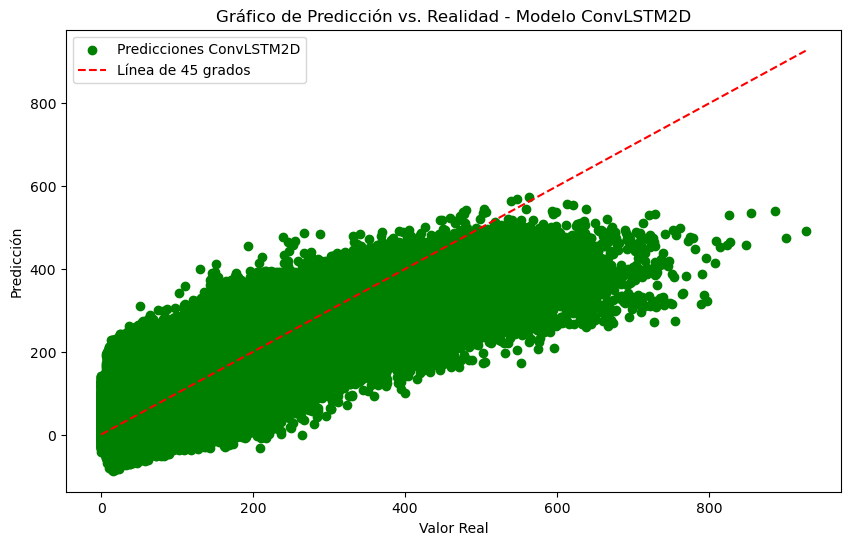

In [19]:
import matplotlib.pyplot as plt


# Gráfico de Predicción vs. Realidad para el modelo ConvLSTM2D
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_conv_lstm, color='green', label='Predicciones ConvLSTM2D')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', label='Línea de 45 grados')
plt.xlabel('Valor Real')
plt.ylabel('Predicción')
plt.title('Gráfico de Predicción vs. Realidad - Modelo ConvLSTM2D')
plt.legend()
plt.show()


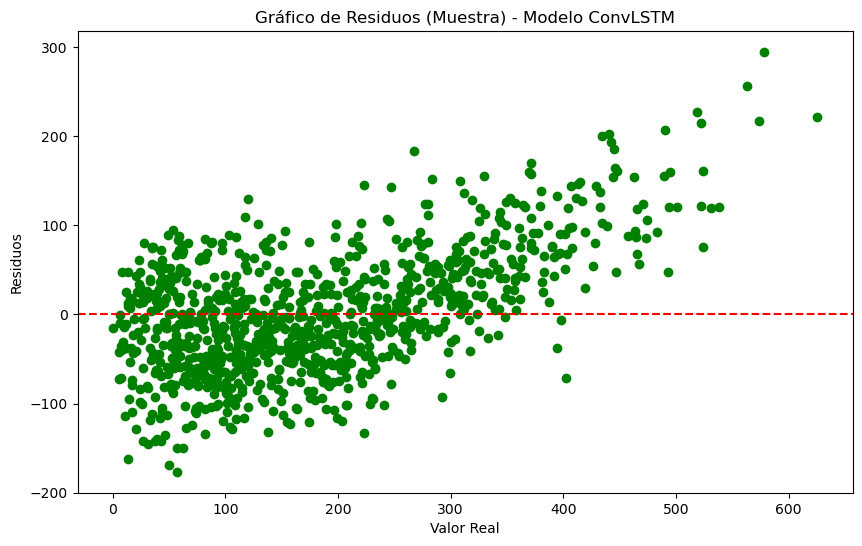

In [20]:
import random

# Elegir una muestra aleatoria de índices
sample_indices = random.sample(range(len(y_test)), k=1000)  # Cambia el valor de 'k' según lo necesites

# Crear una lista para almacenar los residuos de la muestra
sample_residues_conv_lstm = [y_test[i] - y_pred_conv_lstm[i] for i in sample_indices]

# Gráfico de Residuos para el modelo LSTM
plt.figure(figsize=(10, 6))
plt.scatter(y_test[sample_indices], sample_residues_conv_lstm, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valor Real')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos (Muestra) - Modelo ConvLSTM')
plt.show()


